# IMPORTING LIBRARIES

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOADING DATA

In [3]:
sentiment = pd.read_csv(r"../data/sentiment.csv")
trades = pd.read_csv(r"../data/trades.csv")

In [4]:
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [5]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [6]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


# DATA CLEANING

In [7]:
trades = trades.dropna()

In [8]:
trades = trades.drop_duplicates()

In [9]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [10]:
sentiment.rename(columns={
    'date': 'Date',
    'classification': 'Classification'
}, inplace=True)

# CONVERTING DATA

In [11]:
sentiment['Date'] = pd.to_datetime(sentiment['Date']).dt.date

In [12]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [13]:
trades['Date'] = pd.to_datetime(trades['Timestamp'], unit='ms').dt.date

In [14]:
print(trades[['Timestamp', 'Date']].head())

      Timestamp        Date
0  1.730000e+12  2024-10-27
1  1.730000e+12  2024-10-27
2  1.730000e+12  2024-10-27
3  1.730000e+12  2024-10-27
4  1.730000e+12  2024-10-27


<!-- MERGING DATASETS -->

In [15]:
df = pd.merge(trades, sentiment, on='Date', how='left')

# FEATURE ENGINEERING

In [16]:
df['Win'] = (df['Closed PnL'] > 0).astype(int)

# CORE ANALYSIS

In [17]:
analysis = df.groupby('Classification').agg({
    'Closed PnL': 'mean',
    'Win': 'mean',
    'Size USD': 'mean'
}).reset_index()

print(analysis)

  Classification  Closed PnL       Win     Size USD
0  Extreme Greed   25.418772  0.490089  5660.265764
1           Fear   50.047622  0.415146  5259.977837
2          Greed   87.894859  0.446471  3182.883845
3        Neutral   22.229713  0.317182  3058.848110


# VISUALIZATION

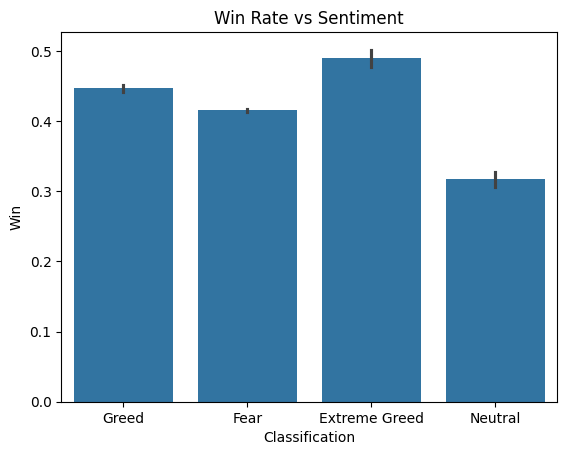

In [18]:
sns.barplot(x='Classification', y='Win', data=df)
plt.title("Win Rate vs Sentiment")
plt.show()

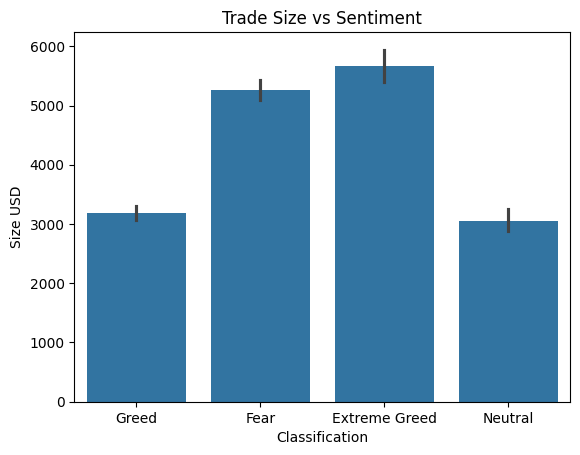

In [19]:
sns.barplot(x='Classification', y='Size USD', data=df)
plt.title("Trade Size vs Sentiment")
plt.show()

In [20]:
trader_counts = df['Account'].value_counts()

df['Trader Type'] = df['Account'].apply(
    lambda x: 'Frequent' if trader_counts[x] > 20 else 'Infrequent'
)

seg = df.groupby(['Trader Type', 'Classification'])['Closed PnL'].mean()
print(seg)

Trader Type  Classification
Frequent     Extreme Greed     25.418772
             Fear              50.047622
             Greed             87.894859
             Neutral           22.229713
Name: Closed PnL, dtype: float64


In [21]:
seg = df.groupby(['Trader Type', 'Classification'])['Closed PnL'].mean().reset_index()
print(seg)

  Trader Type Classification  Closed PnL
0    Frequent  Extreme Greed   25.418772
1    Frequent           Fear   50.047622
2    Frequent          Greed   87.894859
3    Frequent        Neutral   22.229713


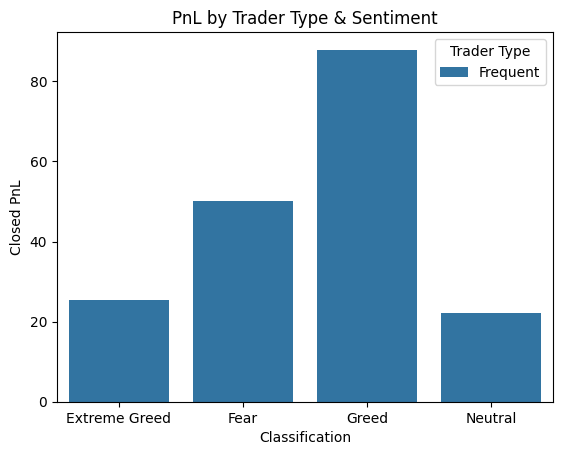

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Classification', y='Closed PnL', hue='Trader Type', data=seg)
plt.title("PnL by Trader Type & Sentiment")
plt.show()

# STRATAGY

# Strategy 1: Risk Control During Greed Phases

During Greed periods, traders achieve the highest average PnL, indicating strong market trends. However, the win rate is not proportionally high, suggesting increased volatility and risk.

# Recommendation:

Limit position size despite bullish conditions
Avoid overtrading during strong upward trends
Use strict stop-loss mechanisms

# Rationale:
High profits in Greed come with higher uncertainty, so disciplined risk management improves consistency.

# Strategy 2: Avoid Overexposure During Fear

During Fear periods, traders tend to take larger position sizes, but this does not result in better win rates.

# Recommendation:

Reduce trade size during Fear
Avoid aggressive positions
Focus on capital preservation

# Rationale: 
Larger trades in uncertain markets lead to inefficient risk-taking and lower success rates.

# Strategy 3: Trade Selectively During Extreme Greed

Extreme Greed shows higher win rate but lower PnL, indicating frequent small gains.

# Recommendation:

Use short-term trading strategies (scalping)
Take profits quickly
Avoid holding positions too long

# Rationale:
Market conditions favor frequent small wins rather than large directional bet